In [1]:
!pip install ultralytics opencv-python google-generativeai pandas matplotlib pillow streamlit

In [2]:
from ultralytics import YOLO
import pandas as pd
import google.generativeai as genai
from PIL import Image
import matplotlib.pyplot as plt
import csv
import os

c:\Users\abhin\Desktop\DataScience\Deep Learning\project\env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\abhin\Desktop\DataScience\Deep Learning\project\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\abhin\AppData\Local\Temp\ipykernel_19932\12603015.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package a

In [3]:
genai.configure(api_key=os.getenv("GOOGLE_API_KEY1"))
model = genai.GenerativeModel('models/gemini-2.5-flash')

In [4]:
model_yolo = YOLO("yolov8n.pt")

In [5]:
def detect(image_path):
    results = model_yolo(image_path)
    result = results[0]
    detected = [result.names[int(cls)] for cls in result.boxes.cls]
    return list(set(detected)), result.plot()

In [6]:
def analyze_with_gemini(image_path):
    image = Image.open(image_path)
    prompt = """Check PPE compliance.
Helmet: Yes/No
Vest: Yes/No
Status: SAFE/UNSAFE
Reason:"""
    response = model.generate_content([prompt, image])
    return response.text

In [7]:
def save_log(items, analysis):
    with open("logs.csv", "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([",".join(items), analysis])

In [8]:
def retrieve_context():
    try:
        df = pd.read_csv("logs.csv", names=["items", "analysis"])
        return "\n".join(df['analysis'].tail(5))
    except:
        return "No previous data." 

In [9]:
def rag_chatbot(question, latest_analysis):
    context = retrieve_context()
    prompt = f"""
Context:
{context}

Latest:
{latest_analysis}

Question:
{question}
"""
    response = model.generate_content(prompt)
    return response.text


image 1/1 c:\Users\abhin\Desktop\DataScience\Deep Learning\project\1\pic-5-combo-3.webp: 640x640 1 person, 72.5ms
Speed: 4.2ms preprocess, 72.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Detected: ['person']
Analysis: Helmet: Yes
Vest: Yes
Status: SAFE
Reason: The worker is wearing a helmet (hard hat), a high-visibility vest, and safety gloves, all of which are appropriate Personal Protective Equipment for a construction site.


(-0.5, 999.5, 999.5, -0.5)

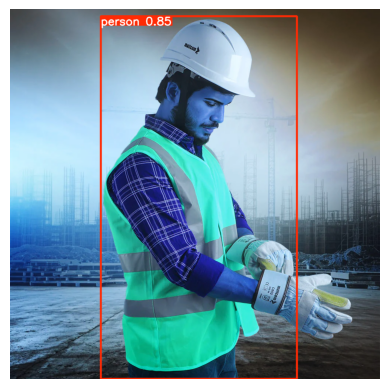

In [10]:
# Run pipeline
image_path = "pic-5-combo-3.webp"

items, img = detect(image_path)
analysis = analyze_with_gemini(image_path)

print("Detected:", items)
print("Analysis:", analysis)

save_log(items, analysis)

plt.imshow(img)
plt.axis("off")

In [ ]:
# Chatbot
while True:
    q = input("You: ")
    if q == "exit":
        break
    print("Bot:", rag_chatbot(q, analysis))

Bot: Yes, based on the information provided, this situation is **significantly safer**.

The "Reason" explicitly states that the worker is wearing **appropriate Personal Protective Equipment (PPE)** for a construction site:

*   **Helmet (hard hat):** Protects against head injuries from falling objects, impacts, or bumps.
*   **High-visibility vest:** Ensures the worker is easily seen by vehicle operators and other personnel, reducing the risk of being struck.
*   **Safety gloves:** Protect hands from cuts, abrasions, punctures, chemicals, or other hazards.

These items are crucial for preventing injuries in a hazardous environment like a construction site. Without them, the worker would be at a much higher risk.
Bot: Yes.

The provided reason explicitly states that the worker is wearing "appropriate Personal Protective Equipment" (PPE) for a construction site, which directly contributes to a "SAFE" status. Wearing appropriate PPE makes a situation safer.
Bot: Based on the latest infor

In [1]:
print(model_yolo.names)

NameError: name 'model_yolo' is not defined